### **[Six Matplotlib Changes That Improve Your Figures for Reporting and Publication](https://medium.com/data-science-collective/3cd07d882bec)**

In [1]:
import sys

import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

IN_COLAB = "google.colab" in sys.modules

%autosave 15

Autosaving every 15 seconds


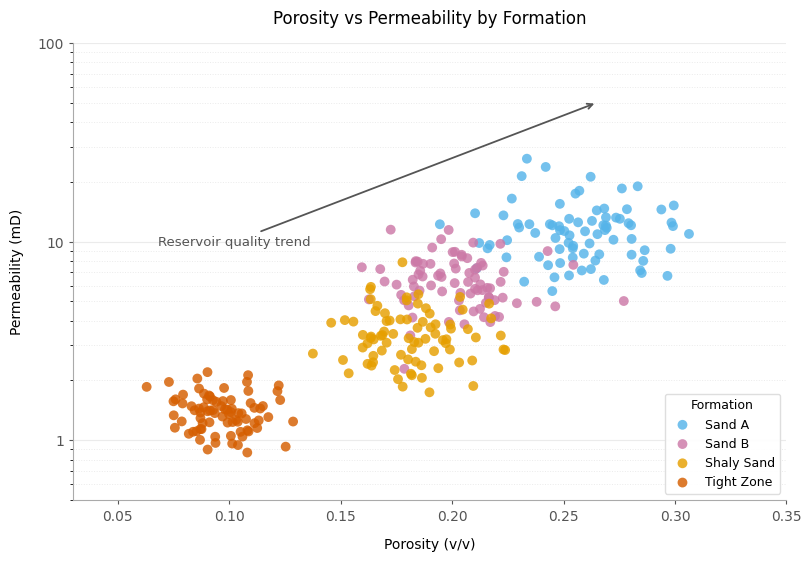

In [2]:
# ── Synthetic dataset
np.random.seed(42)
n = 80

formations_params = {
  "Sand A":     {"phi_mean": 0.26, "phi_std": 0.025, "perm_mu": 2.4, "perm_sigma": 0.35},
  "Sand B":     {"phi_mean": 0.20, "phi_std": 0.020, "perm_mu": 1.8, "perm_sigma": 0.30},
  "Shaly Sand": {"phi_mean": 0.18, "phi_std": 0.020, "perm_mu": 1.2, "perm_sigma": 0.28},
  "Tight Zone": {"phi_mean": 0.10, "phi_std": 0.015, "perm_mu": 0.3, "perm_sigma": 0.20},
}

frames = []
for name, p in formations_params.items():
  phi  = np.clip(np.random.normal(p["phi_mean"], p["phi_std"], n), 0.04, 0.35)
  perm = np.random.lognormal(p["perm_mu"], p["perm_sigma"], n)
  frames.append(pd.DataFrame({"Formation": name, "Porosity": phi, "Permeability": perm}))
df = pd.concat(frames, ignore_index=True)

# ── Palette
PALETTE = {
  "Sand A":     "#56B4E9",   # sky blue
  "Sand B":     "#CC79A7",   # reddish purple
  "Shaly Sand": "#E69F00",   # golden amber
  "Tight Zone": "#D55E00",   # vermillion
}

def apply_clean_style(ax, yscale="linear"):
  ax.set_facecolor("white")
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.spines["left"].set_color("#aaaaaa")
  ax.spines["bottom"].set_color("#aaaaaa")
  ax.yaxis.grid(True, color="#ebebeb", linewidth=0.8, zorder=0)
  ax.xaxis.grid(False)
  ax.set_axisbelow(True)
  ax.tick_params(axis="both", colors="#555555", length=3, width=0.8)
  if yscale == "log":
    ax.set_yscale("log")

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
fig.patch.set_facecolor("white")

for formation, group in df.groupby("Formation"):
  ax.scatter(
    group["Porosity"], group["Permeability"],
    label=formation,
    color=PALETTE[formation],
    s=50, alpha=0.82, edgecolors="none"
  )

apply_clean_style(ax, yscale="log")

perm_max = df["Permeability"].max()
top = 10 ** math.ceil(math.log10(perm_max))
ax.set_ylim(bottom=0.5, top=top)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.yaxis.grid(True, which="minor", color="#ebebeb", linewidth=0.7, linestyle=":")

ax.set_xlabel("Porosity (v/v)", labelpad=10)
ax.set_ylabel("Permeability (mD)", labelpad=10)
ax.set_title("Porosity vs Permeability by Formation", pad=14)
ax.set_xlim(0.03, 0.35)

ax.annotate(
  "Reservoir quality trend",
  xy=(0.265, 50),
  xytext=(0.068, 10),
  fontsize=9.5,
  color="#555555",
  rotation=0,
  arrowprops=dict(arrowstyle="->", color="#555555", lw=1.3),
  va="center",
  ha="left",
)

ax.legend(title="Formation", title_fontsize=9, fontsize=9,
        frameon=True, framealpha=0.95, edgecolor="#dddddd",
        loc="lower right")

if not IN_COLAB:
  fig.savefig("porosity_permeability.png", dpi=300, bbox_inches="tight")

plt.show()